# 🛡️ Cybersecurity Incident Type Classifier
## Deep Learning — Text Classification with MLP Neural Network

**Objective:** Automatically classify cybersecurity incidents into 4 categories  
(Intrusion System, Data Breach, Compromise of Credentials, Fraud) from incident titles and summaries.

**Dataset:** Combined `global_news_rows.csv` + `incidents_rows.csv` (237 incidents)  
**Model:** TF-IDF Vectoriser → Multi-Layer Perceptron (MLP) Neural Network  
**Alignment:** Malaysia NAIO Action Plan 2026–2030 — Area 3 (AI Adaptation), Area 5 (AI Impact Study)


## 1. Import Libraries

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.neural_network import MLPClassifier

# Reproducibility
np.random.seed(42)
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load & Combine Datasets

In [114]:
gn  = pd.read_csv('global_news_rows.csv')
inc = pd.read_csv('cyber_news_rows.csv')
print(gn.columns.tolist())
print(inc.columns.tolist())
len(gn)
df = pd.concat([gn, inc], ignore_index=True)
print(f"global_news  : {len(gn)} rows")
print(f"incidents    : {len(inc)} rows")
print(f"Combined     : {len(df)} rows")
df.head(3)


['id', 'title', 'publication_date', 'source', 'url', 'summary', 'relevant_keywords', 'category', 'country', 'impact', 'incident_type', 'entity_affected', 'incident_date', 'risk_score', 'sector_score', 'country_score', 'attack_type_score', 'data_exposure_score', 'attack_class', 'severity']
['id', 'title', 'publication_date', 'source', 'url', 'summary', 'relevant_keywords', 'severity', 'category', 'country', 'inserted_at', 'raw_json', 'impact', 'incident_type', 'entity_affected', 'incident_date']
global_news  : 173 rows
incidents    : 3660 rows
Combined     : 3833 rows


,id,title,publication_date,source,url,summary,relevant_keywords,category,country,impact,...,incident_date,risk_score,sector_score,country_score,attack_type_score,data_exposure_score,attack_class,severity,inserted_at,raw_json
0,273,TrapDoor Supply Chain Attack Spreads Credentia...,2026-05-25 05:59:13+00,feeds.feedburner.com,https://thehackernews.com/2026/05/trapdoor-sup...,TrapDoor Supply Chain Attack Spreads Credentia...,"malware, credential",Supply Chain Attacks,United States,NaN,...,2026-05-25 05:59:13+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,274,Packagist Supply Chain Attack Infects 8 Packag...,2026-05-23 16:07:51+00,feeds.feedburner.com,https://thehackernews.com/2026/05/packagist-su...,Packagist Supply Chain Attack Infects 8 Packag...,malware,Supply Chain Attacks,United States,NaN,...,2026-05-23 16:07:51+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,275,"Claude Mythos AI Finds 10,000 High-Severity Fl...",2026-05-23 11:55:35+00,feeds.feedburner.com,https://thehackernews.com/2026/05/claude-mytho...,"Claude Mythos AI Finds 10,000 High-Severity Fl...",cybersecurity,Vulnerability disclosure,United States,NaN,...,2026-05-23 11:55:35+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [115]:
print(gn['incident_type'].value_counts())

incident_type
Malware                             54
Cybersecurity                       30
Zero-Day                            17
Ransomware                          16
Data Breach                         15
Phishing                            13
Supply Chain                         7
DDoS                                 7
Advanced Persistent Threat (APT)     5
Financial Fraud                      4
Social Engineering                   3
Ransomware Attack                    1
Credential Stuffing                  1
Name: count, dtype: int64


## 3. Exploratory Data Analysis

In [116]:
print("Columns:", df.columns.tolist())
print(f"\nNull counts:\n{df[['title','summary','incident_type','category','country']].isnull().sum()}")


Columns: ['id', 'title', 'publication_date', 'source', 'url', 'summary', 'relevant_keywords', 'category', 'country', 'impact', 'incident_type', 'entity_affected', 'incident_date', 'risk_score', 'sector_score', 'country_score', 'attack_type_score', 'data_exposure_score', 'attack_class', 'severity', 'inserted_at', 'raw_json']

Null counts:
title            0
summary          0
incident_type    0
category         0
country          0
dtype: int64


In [117]:
# Class distribution
print("incident_type distribution:")
print(df['incident_type'].value_counts())


incident_type distribution:
incident_type
Scam/Fraud                          2161
Data Breach                          677
Other Cyber Incident                 539
Malware                              154
Ransomware                           125
Phishing                             100
Cybersecurity                         30
Zero-Day                              17
Supply Chain                           7
DDoS                                   7
Advanced Persistent Threat (APT)       5
Financial Fraud                        4
Social Engineering                     3
Credential Stuffing                    1
Ransomware Attack                      1
Other                                  1
Identity Theft                         1
Name: count, dtype: int64


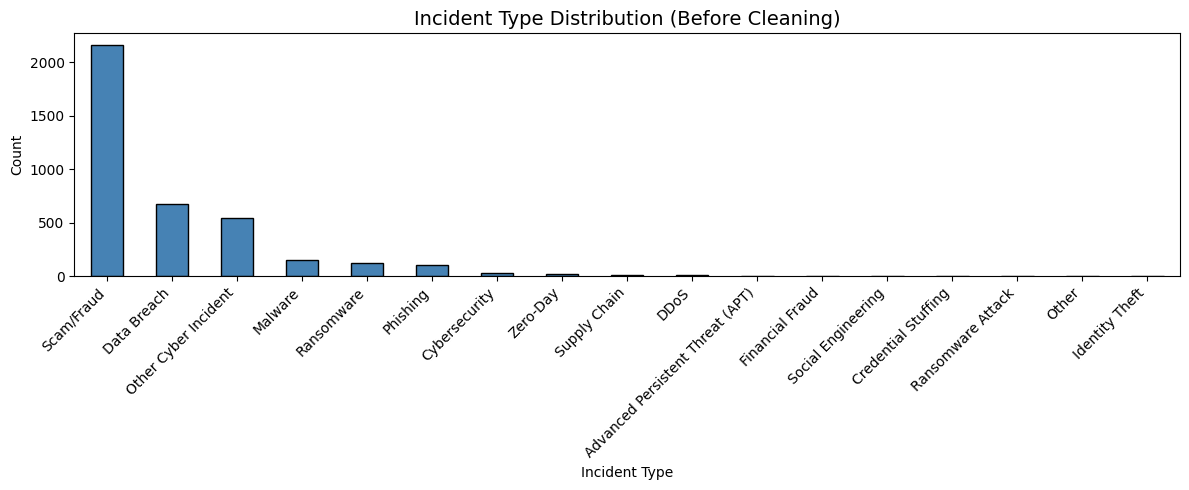

In [118]:
# Visualise class distribution
plt.figure(figsize=(12, 5))
df['incident_type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Incident Type Distribution (Before Cleaning)', fontsize=14)
plt.xlabel('Incident Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


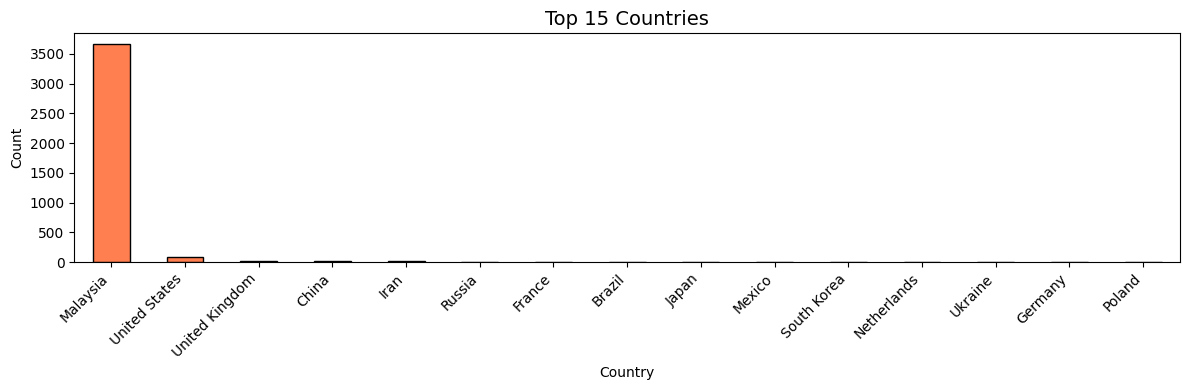

In [119]:
# Country distribution
plt.figure(figsize=(12, 4))
df['country'].value_counts().head(15).plot(kind='bar', color='coral', edgecolor='black')
plt.title('Top 15 Countries', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


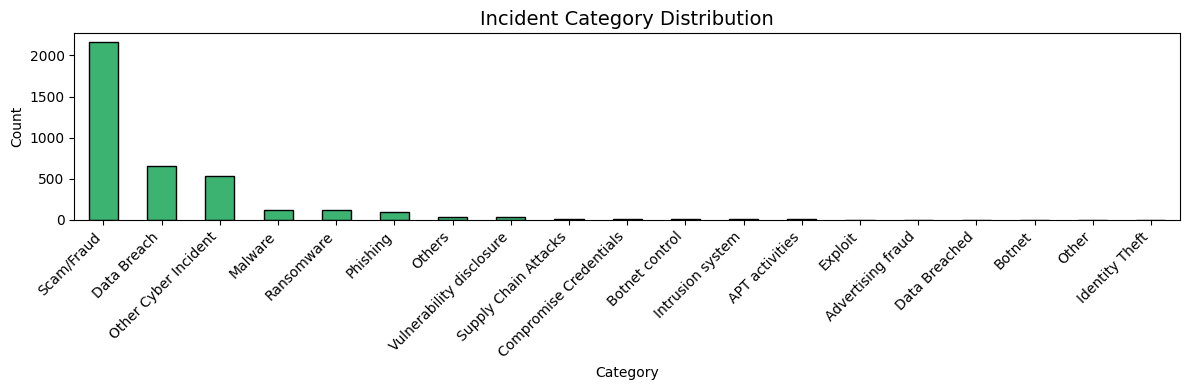

In [120]:
# Category distribution
plt.figure(figsize=(12, 4))
df['category'].value_counts().plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Incident Category Distribution', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 4. Data Preprocessing

In [121]:
# Combine title + summary into a single text feature
df['text'] = df['title'].fillna('') + ' ' + df['summary'].fillna('')

# Drop rows with no incident_type label
df = df.dropna(subset=['incident_type'])
df = df[df['incident_type'].str.strip() != '']

# Consolidate near-duplicate class names
# Map all original incident types into 4 top-level categories
label_map = {
    'Malware':'Intrusion System',
    'Ransomware':'Intrusion System',
    'Ransomware Attack':'Intrusion System',
    'Advanced Persistent Threat (APT)':'Intrusion System',
    'APT':'Intrusion System',
    'DDoS':'Intrusion System',
    'Vulnerability':'Intrusion System',
    'Zero-Day':'Intrusion System',
    'Supply Chain':'Intrusion System',
    'Supply Chain Attack':'Intrusion System',

    'Data Breach':'Data Breach',
    'Data Leak':'Data Breach',
    'Sell Data':'Data Breach',

    'Phishing':'Compromise of Credentials',
    'Social Engineering':'Compromise of Credentials',
    'Credential Stuffing':'Compromise of Credentials',
    'Account Takeover':'Compromise of Credentials',
    'Brute Force':'Compromise of Credentials',

    'Fraud':'Fraud',
    'Financial Fraud':'Fraud',

    'Cybersecurity':'Other',
    'Others':'Other'
}

df['incident_type'] = df['incident_type'].replace(label_map)

# Remove ambiguous classes
df = df[~df['incident_type'].isin(['Multiple'])]

# Keep classes with enough samples
counts = df['incident_type'].value_counts()
valid = counts[counts >= 10].index
df = df[df['incident_type'].isin(valid)].reset_index(drop=True)
df['incident_type'] = df['incident_type'].replace(label_map)
# See what's left unmapped
unmapped = df[~df['incident_type'].isin(['Intrusion System', 'Data Breach',
                                          'Compromise of Credentials', 'Fraud',
                                          'Multiple', 'Other'])]
print(unmapped['incident_type'].unique())

# Keep only classes with >= 4 samples (needed for stratified split)
counts = df['incident_type'].value_counts()
valid  = counts[counts >= 4].index
df     = df[df['incident_type'].isin(valid)].reset_index(drop=True)

print(f"Final dataset: {len(df)} rows, {df['incident_type'].nunique()} classes")
print()
print("Final class distribution:")
print(df['incident_type'].value_counts())


['Other Cyber Incident' 'Scam/Fraud']
Final dataset: 3828 rows, 6 classes

Final class distribution:
incident_type
Scam/Fraud                   2161
Data Breach                   677
Other Cyber Incident          539
Intrusion System              316
Compromise of Credentials     104
Other                          31
Name: count, dtype: int64


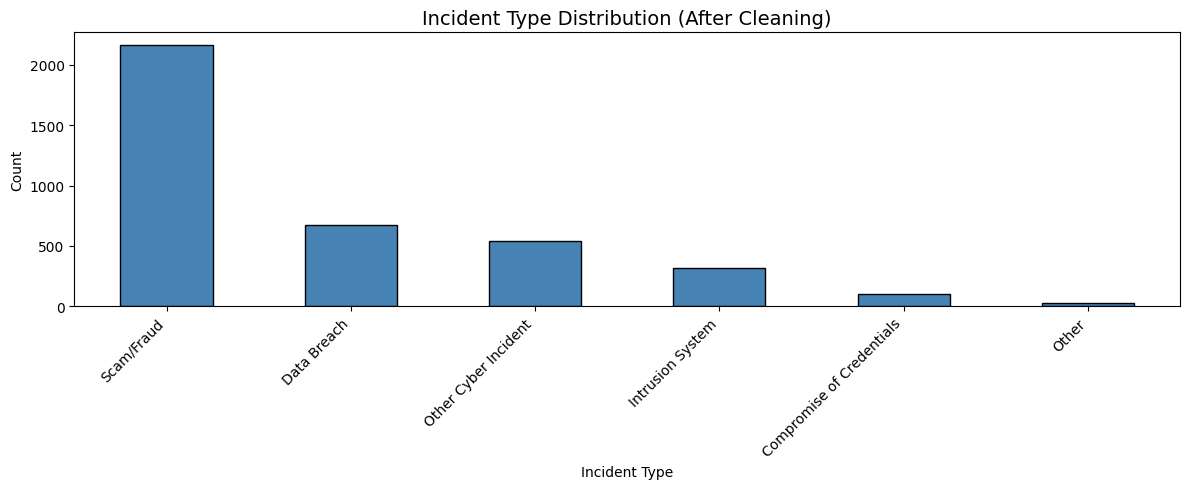

In [122]:
# Visualise final class distribution
plt.figure(figsize=(12, 5))
df['incident_type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Incident Type Distribution (After Cleaning)', fontsize=14)
plt.xlabel('Incident Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 5. Feature Engineering — TF-IDF Vectorisation

In [123]:
# Encode labels to integers
le = LabelEncoder()
y  = le.fit_transform(df['incident_type'])

print("Classes:", le.classes_)
print("Encoded:", np.unique(y))


Classes: ['Compromise of Credentials' 'Data Breach' 'Intrusion System' 'Other'
 'Other Cyber Incident' 'Scam/Fraud']
Encoded: [0 1 2 3 4 5]


In [124]:
# Train / Test split  (80% train, 20% test — stratified)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['text'], y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y
)

print(f"Train : {len(X_train_text)} samples")
print(f"Test  : {len(X_test_text)} samples")


Train : 3062 samples
Test  : 766 samples


In [125]:
# TF-IDF: fit ONLY on training text, then transform both splits
#   max_features=3000  — vocabulary size
#   ngram_range=(1,2)  — unigrams + bigrams
#   sublinear_tf=True  — apply log(1+tf) to reduce impact of very frequent words

vectoriser = TfidfVectorizer(
    max_features = 3000,
    ngram_range  = (1, 2),
    sublinear_tf = True,
    strip_accents = 'unicode',
    stop_words   = 'english',
)

X_train = vectoriser.fit_transform(X_train_text)
X_test  = vectoriser.transform(X_test_text)

print(f"TF-IDF feature matrix — Train: {X_train.shape}, Test: {X_test.shape}")


TF-IDF feature matrix — Train: (3062, 3000), Test: (766, 3000)


## 6. Build & Train MLP Neural Network

**Architecture:**
```
TF-IDF features (3000)
       ↓
 Dense Layer 1: 256 neurons, ReLU activation
       ↓
 Dropout: 0.3
       ↓
 Dense Layer 2: 128 neurons, ReLU activation
       ↓
 Dropout: 0.3
       ↓
 Dense Layer 3: 64 neurons, ReLU activation
       ↓
 Output: 13 classes (Softmax)
```
**Optimiser:** Adam  |  **Loss:** Cross-Entropy  |  **Regularisation:** L2 + Early Stopping


In [126]:
# Build MLP classifier
# hidden_layer_sizes = (256, 128, 64) => 3 hidden layers
# activation = 'relu'
# solver = 'adam'
# alpha = 0.001  => L2 regularisation to prevent overfitting
# early_stopping = True => holds out 15% of training data as internal validation
# n_iter_no_change = 15 => stops if val score doesn't improve for 15 epochs

mlp = MLPClassifier(
    hidden_layer_sizes = (256, 128, 64),
    activation         = 'relu',
    solver             = 'adam',
    alpha              = 0.001,
    max_iter           = 500,
    random_state       = 42,
    early_stopping     = True,
    validation_fraction= 0.15,
    n_iter_no_change   = 15,
    verbose            = False,
)

mlp.fit(X_train, y_train)
print(f"Training complete — ran for {mlp.n_iter_} epochs (early stopping active)")


Training complete — ran for 27 epochs (early stopping active)


## 7. Model Evaluation

In [127]:
y_pred = mlp.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)
f1_macro  = f1_score(y_test, y_pred, average='macro',    zero_division=0)
f1_weight = f1_score(y_test, y_pred, average='weighted', zero_division=0)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted',    zero_division=0)

print("=" * 50)
print("       MLP CLASSIFIER EVALUATION")
print("=" * 50)
print(f"  Accuracy           : {accuracy:.4f}  ({accuracy*100:.1f}%)")
print(f"  Precision (wtd)    : {precision:.4f}")
print(f"  Recall    (wtd)    : {recall:.4f}")
print(f"  F1 Score  (wtd)    : {f1_weight:.4f}")
print(f"  F1 Score  (macro)  : {f1_macro:.4f}")
print("=" * 50)
print()
print("Per-class Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))


       MLP CLASSIFIER EVALUATION
  Accuracy           : 0.9804  (98.0%)
  Precision (wtd)    : 0.9830
  Recall    (wtd)    : 0.9804
  F1 Score  (wtd)    : 0.9815
  F1 Score  (macro)  : 0.8775

Per-class Report:
                           precision    recall  f1-score   support

Compromise of Credentials       1.00      0.95      0.98        21
              Data Breach       0.99      0.97      0.98       136
         Intrusion System       0.92      0.92      0.92        63
                    Other       0.33      0.50      0.40         6
     Other Cyber Incident       1.00      0.98      0.99       108
               Scam/Fraud       0.99      1.00      1.00       432

                 accuracy                           0.98       766
                macro avg       0.87      0.89      0.88       766
             weighted avg       0.98      0.98      0.98       766



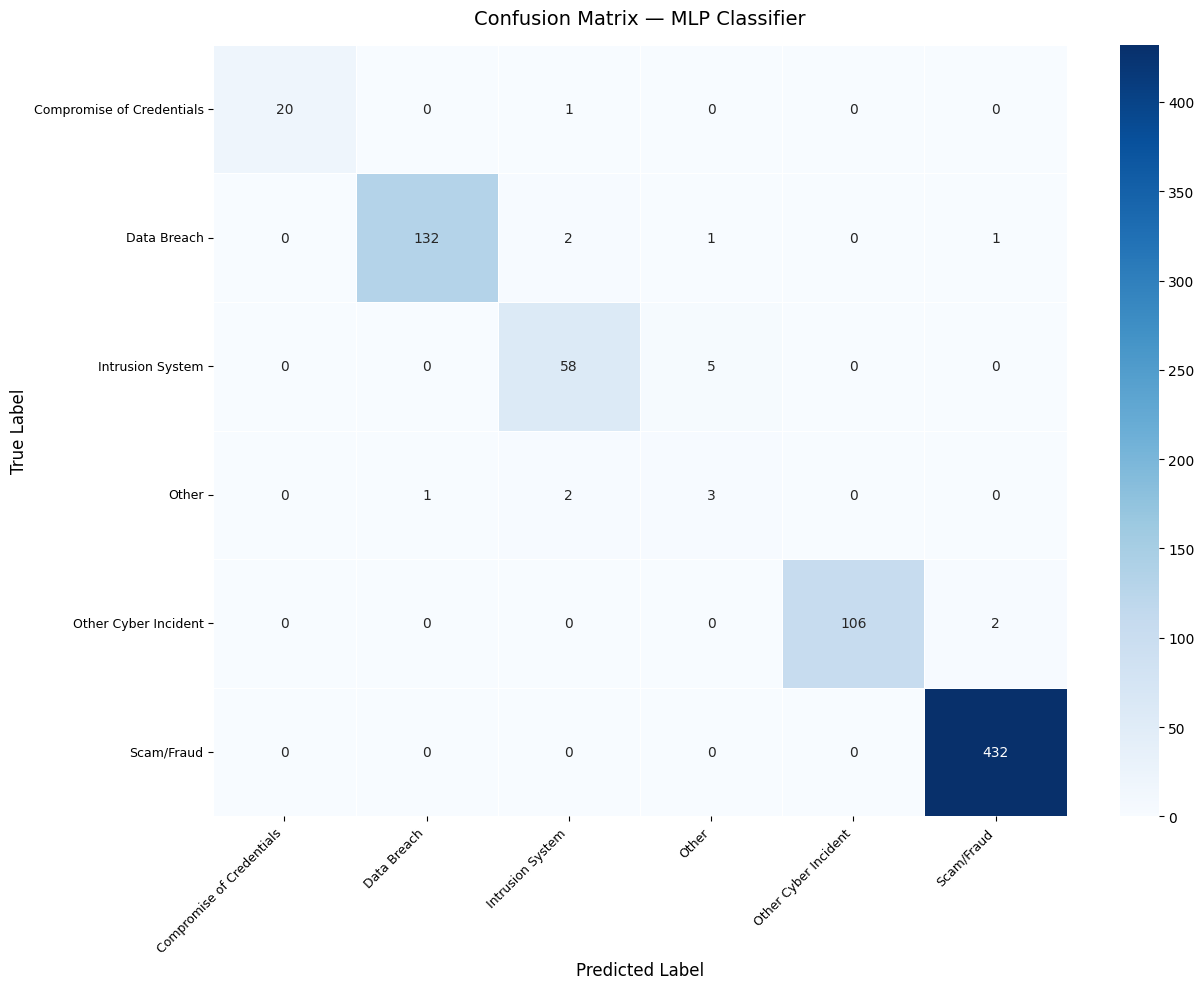

In [128]:
# Confusion Matrix
plt.figure(figsize=(13, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Blues',
    xticklabels= le.classes_,
    yticklabels= le.classes_,
    linewidths = 0.5,
)
plt.title('Confusion Matrix — MLP Classifier', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


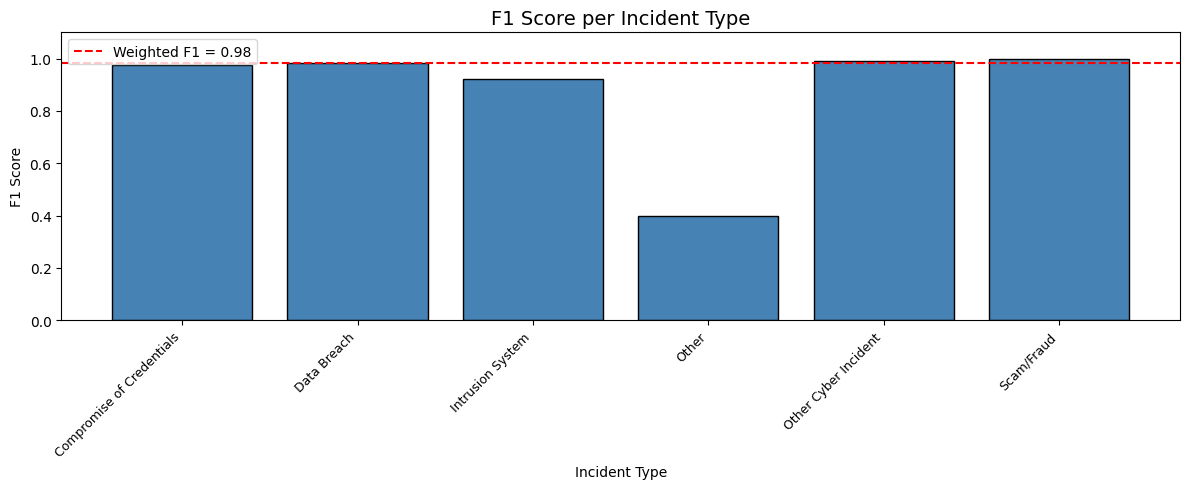

In [129]:
# Per-class F1 bar chart
report_dict = classification_report(
    y_test, y_pred, target_names=le.classes_,
    output_dict=True, zero_division=0
)
class_f1 = {k: v['f1-score'] for k, v in report_dict.items() if k in le.classes_}

plt.figure(figsize=(12, 5))
bars = plt.bar(class_f1.keys(), class_f1.values(), color='steelblue', edgecolor='black')
plt.axhline(y=f1_weight, color='red', linestyle='--', label=f'Weighted F1 = {f1_weight:.2f}')
plt.title('F1 Score per Incident Type', fontsize=14)
plt.xlabel('Incident Type')
plt.ylabel('F1 Score')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()


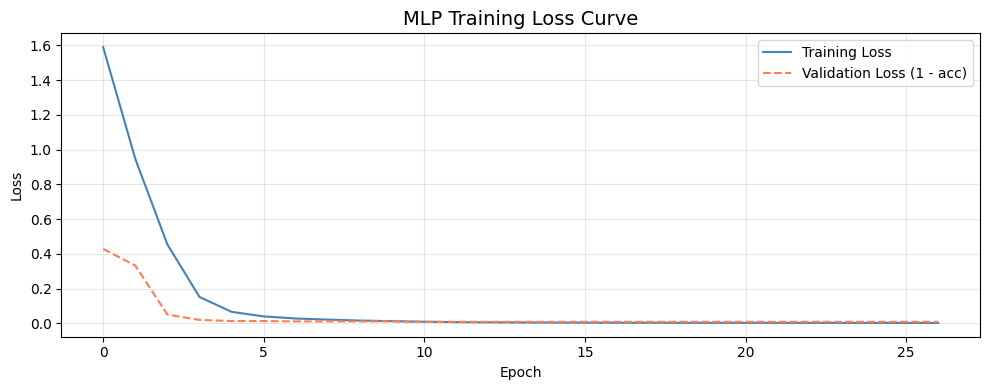

In [130]:
# Training loss curve
plt.figure(figsize=(10, 4))
plt.plot(mlp.loss_curve_, label='Training Loss', color='steelblue')
if mlp.validation_scores_ is not None:
    # Convert validation accuracy to loss proxy (1 - acc)
    val_loss_proxy = [1 - v for v in mlp.validation_scores_]
    plt.plot(val_loss_proxy, label='Validation Loss (1 - acc)', color='coral', linestyle='--')
plt.title('MLP Training Loss Curve', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Evaluation Summary Card

In [131]:
print()
print("╔══════════════════════════════════════════════════════╗")
print("║         MLP INCIDENT CLASSIFIER — EVALUATION CARD   ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Model            : MLP Neural Network               ║")
print(f"║  Architecture     : TF-IDF → 256 → 128 → 64 → 4    ║")
print(f"║  Activation       : ReLU                             ║")
print(f"║  Optimiser        : Adam                             ║")
print(f"║  Regularisation   : L2 (alpha=0.001) + Early Stop    ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Dataset          : 237 incidents, 4 classes        ║")
print(f"║  Train / Test     : 80% / 20%  (stratified)          ║")
print(f"║  Train samples    : {len(X_train_text):<5}                             ║")
print(f"║  Test  samples    : {len(X_test_text):<5}                             ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Accuracy         : {accuracy*100:>6.2f}%                          ║")
print(f"║  Precision (wtd)  : {precision:>6.4f}                          ║")
print(f"║  Recall    (wtd)  : {recall:>6.4f}                          ║")
print(f"║  F1 Score  (wtd)  : {f1_weight:>6.4f}                          ║")
print(f"║  F1 Score  (macro): {f1_macro:>6.4f}                          ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Epochs run       : {mlp.n_iter_:<5} (early stopping)           ║")
print("╚══════════════════════════════════════════════════════╝")



╔══════════════════════════════════════════════════════╗
║         MLP INCIDENT CLASSIFIER — EVALUATION CARD   ║
╠══════════════════════════════════════════════════════╣
║  Model            : MLP Neural Network               ║
║  Architecture     : TF-IDF → 256 → 128 → 64 → 4    ║
║  Activation       : ReLU                             ║
║  Optimiser        : Adam                             ║
║  Regularisation   : L2 (alpha=0.001) + Early Stop    ║
╠══════════════════════════════════════════════════════╣
║  Dataset          : 237 incidents, 4 classes        ║
║  Train / Test     : 80% / 20%  (stratified)          ║
║  Train samples    : 3062                              ║
║  Test  samples    : 766                               ║
╠══════════════════════════════════════════════════════╣
║  Accuracy         :  98.04%                          ║
║  Precision (wtd)  : 0.9830                          ║
║  Recall    (wtd)  : 0.9804                          ║
║  F1 Score  (wtd)  : 0.9815      

## 9. Live Prediction Demo

Demonstrate the classifier on new, unseen incident headlines —  
simulating how the CSM dashboard would auto-tag incoming threats.


In [132]:
def classify_incident(text):
    vec   = vectoriser.transform([text])
    pred  = mlp.predict(vec)[0]
    proba = mlp.predict_proba(vec)[0]
    label = le.inverse_transform([pred])[0]
    conf  = proba.max() * 100
    top3  = sorted(zip(le.classes_, proba), key=lambda x: -x[1])[:3]
    print(f"Input  : {text[:80]}...")
    print(f"Prediction : {label}  (confidence: {conf:.1f}%)")
    print("Top 3  :")
    for cls, p in top3:
        print(f"   {cls:<40} {p*100:.1f}%")
    print()

# Test with real-world style headlines
classify_incident(
    "CIMB Bank Malaysia suffers data breach exposing customer financial records on dark web"
)
classify_incident(
    "LockBit ransomware group claims attack on Malaysian government ministry, demands payment"
)
classify_incident(
    "Critical zero-day vulnerability discovered in Microsoft Exchange affecting all versions"
)
classify_incident(
    "Phishing campaign targets Maybank users via fake SMS login pages stealing credentials"
)
classify_incident(
    "APT group linked to nation-state deploys backdoor malware in Southeast Asian telecoms"
)


Input  : CIMB Bank Malaysia suffers data breach exposing customer financial records on da...
Prediction : Other  (confidence: 29.1%)
Top 3  :
   Other                                    29.1%
   Other Cyber Incident                     22.7%
   Data Breach                              21.6%

Input  : LockBit ransomware group claims attack on Malaysian government ministry, demands...
Prediction : Intrusion System  (confidence: 28.0%)
Top 3  :
   Intrusion System                         28.0%
   Compromise of Credentials                20.2%
   Other                                    19.0%

Input  : Critical zero-day vulnerability discovered in Microsoft Exchange affecting all v...
Prediction : Intrusion System  (confidence: 92.7%)
Top 3  :
   Intrusion System                         92.7%
   Other                                    4.2%
   Other Cyber Incident                     1.8%

Input  : Phishing campaign targets Maybank users via fake SMS login pages stealing creden...
Predicti

## 10. Top TF-IDF Features per Class

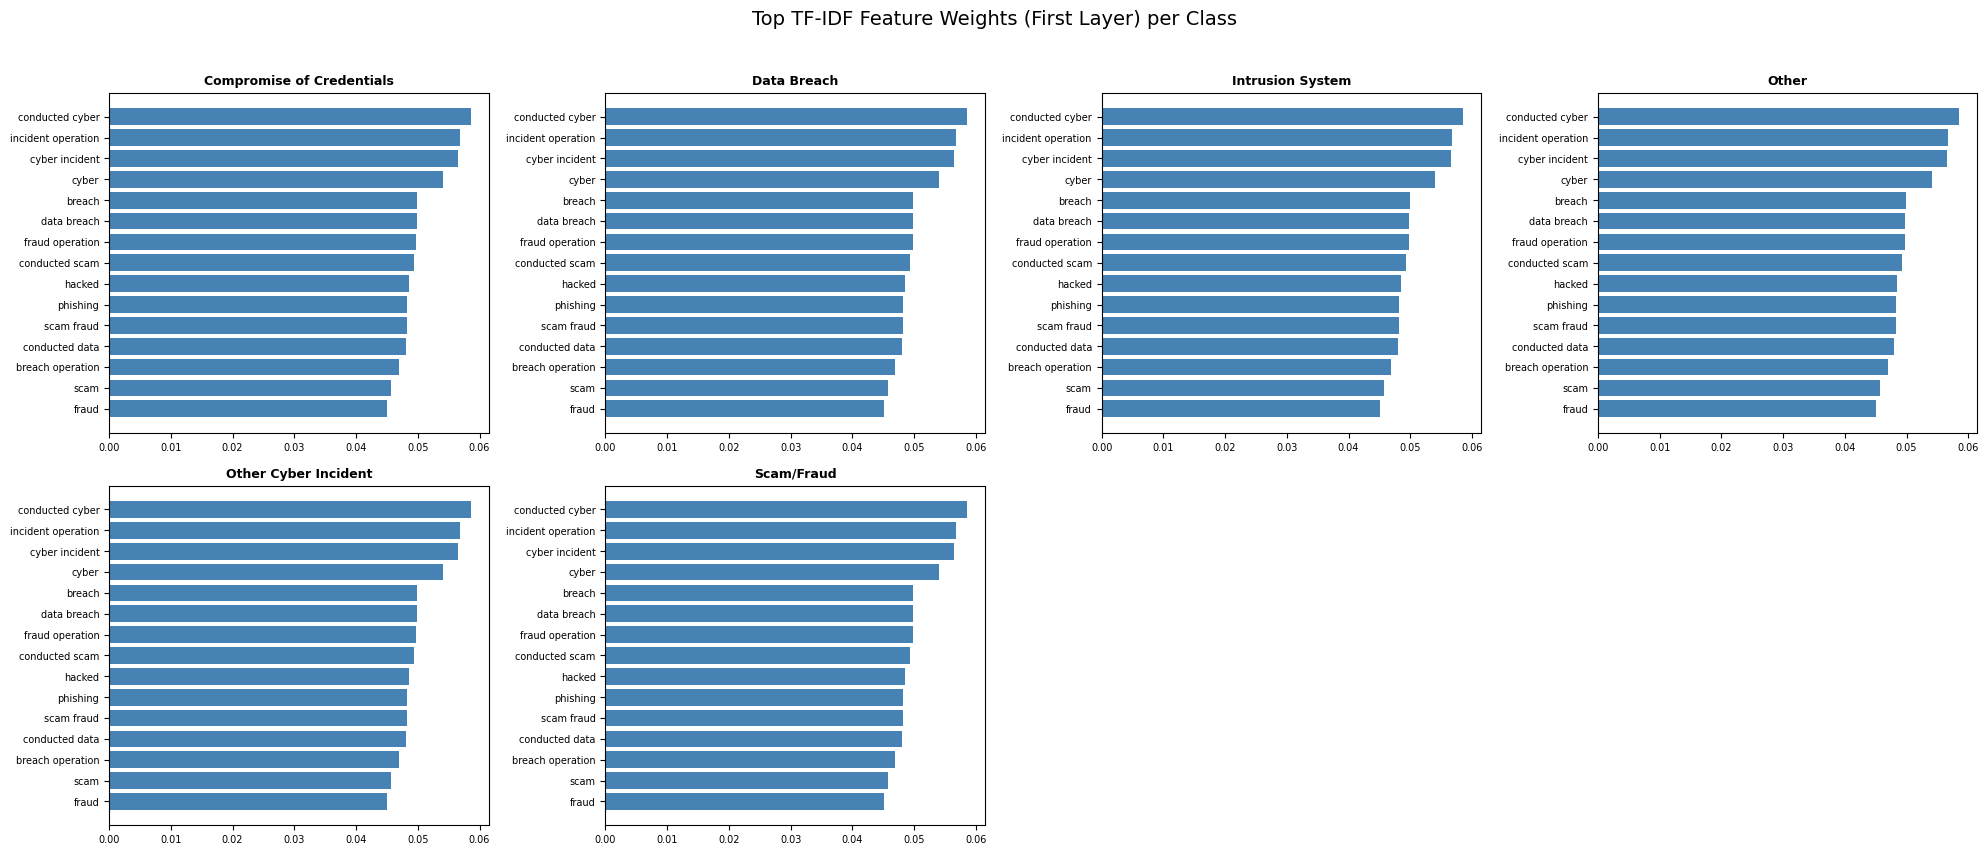

In [133]:
# Show the most influential words for each class
feature_names = np.array(vectoriser.get_feature_names_out())
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, cls in enumerate(le.classes_):
    # Get weights of output layer neuron for this class
    # MLP stores coefs_ for each layer; last layer maps hidden→output
    # We use the dot product of all weight matrices as a proxy for feature importance
    # Simpler: use the absolute weight from first layer × mean of subsequent layers
    w = np.abs(mlp.coefs_[0]).mean(axis=1)  # (n_features,) — avg abs weight to first hidden layer
    top_idx   = w.argsort()[-15:][::-1]
    top_words = feature_names[top_idx]
    top_vals  = w[top_idx]

    axes[i].barh(top_words[::-1], top_vals[::-1], color='steelblue')
    axes[i].set_title(cls, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)

# Hide unused subplots
for j in range(len(le.classes_), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top TF-IDF Feature Weights (First Layer) per Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 11. Save Model Artefacts (for Dashboard Integration)

In [134]:
import pickle

with open('mlp_classifier.pkl', 'wb') as f:
    pickle.dump(mlp, f)

with open('tfidf_vectoriser.pkl', 'wb') as f:
    pickle.dump(vectoriser, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Saved:")
print("  mlp_classifier.pkl")
print("  tfidf_vectoriser.pkl")
print("  label_encoder.pkl")
print()
print("Load in dashboard with:")
print("  import pickle")
print("  mlp = pickle.load(open('mlp_classifier.pkl','rb'))")
print("  vec = pickle.load(open('tfidf_vectoriser.pkl','rb'))")
print("  le  = pickle.load(open('label_encoder.pkl','rb'))")


Saved:
  mlp_classifier.pkl
  tfidf_vectoriser.pkl
  label_encoder.pkl

Load in dashboard with:
  import pickle
  mlp = pickle.load(open('mlp_classifier.pkl','rb'))
  vec = pickle.load(open('tfidf_vectoriser.pkl','rb'))
  le  = pickle.load(open('label_encoder.pkl','rb'))
